In [2]:
#importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

# Loading  the dataset
file_path = r"C:\Users\sanga\Desktop\Air_Quality_Forecasting\data\raw\Air_Quality_dataset_of_kathmandu.csv"
df = pd.read_csv(file_path)


In [4]:
#first five rows of the datasets
df.head()

,Date,Time,PM10 (μg/m³),PM2.5 (μg/m³),CO (μg/m³),NO2 (μg/m³),SO2 (μg/m³),O3 (μg/m³),Temp (°C),Humidity (%),Wind_Speed (km/h),Soil_Moisture (m³/m³),AQI
0,8/5/2022,0:00:00,31.7,22.2,478,14.1,5.2,27,20.3,98.0,3.1,0.426,58
1,8/5/2022,1:00:00,29.7,20.8,435,11.6,4.5,28,21.0,96.0,1.8,0.425,59
2,8/5/2022,2:00:00,25.3,17.7,374,8.2,3.5,30,21.7,93.0,3.1,0.424,59
3,8/5/2022,3:00:00,23.1,16.2,303,4.3,2.5,32,23.2,86.0,3.1,0.423,60
4,8/5/2022,4:00:00,20.3,14.2,272,2.9,2.0,34,25.1,76.0,2.1,0.421,60


In [5]:
#checking the missing values 
df.isna().sum()

Date                      0
Time                      0
PM10 (μg/m³)              0
PM2.5 (μg/m³)             0
CO (μg/m³)                0
NO2 (μg/m³)               0
SO2 (μg/m³)               0
O3  (μg/m³)               0
Temp (°C)                47
Humidity (%)             47
Wind_Speed (km/h)        47
Soil_Moisture (m³/m³)    47
AQI                       0
dtype: int64

In [8]:
#Handling the missing values 
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.isna().sum()

Date                     0
Time                     0
PM10 (μg/m³)             0
PM2.5 (μg/m³)            0
CO (μg/m³)               0
NO2 (μg/m³)              0
SO2 (μg/m³)              0
O3  (μg/m³)              0
Temp (°C)                0
Humidity (%)             0
Wind_Speed (km/h)        0
Soil_Moisture (m³/m³)    0
AQI                      0
dtype: int64

In [ ]:
#coverting the date and time column to datetime format
try:
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
except Exception as e:
    print("Error parsing Date-Time column:", e)

df.dropna(subset=['Datetime'], inplace=True)
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

In [11]:
# Step 3: Remove Outliers using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
df = df[~outlier_condition.any(axis=1)]

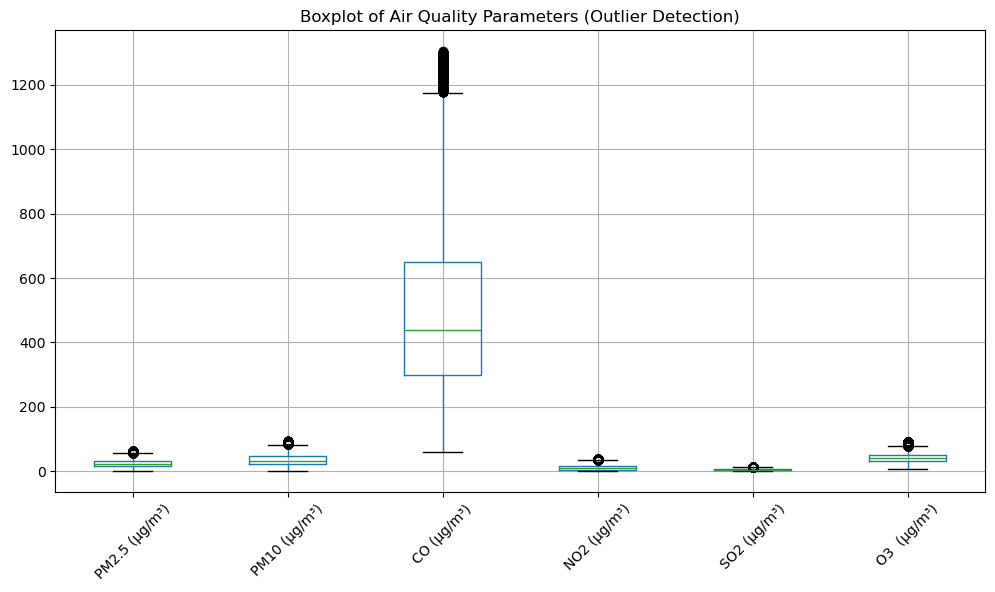

In [16]:
#checking the outliers 
numeric_columns = ['PM2.5 (μg/m³)', 'PM10 (μg/m³)', 'CO (μg/m³)', 'NO2 (μg/m³)', 'SO2 (μg/m³)', 'O3  (μg/m³)']

# Plot boxplots to detect outliers
plt.figure(figsize=(12, 6))
df[numeric_columns].boxplot(rot=45)
plt.title("Boxplot of Air Quality Parameters (Outlier Detection)")
plt.show()



In [19]:
#remove the outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
df = df[~outlier_condition.any(axis=1)]


In [20]:
# Normalize Numerical Features
scaler = MinMaxScaler()
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# Step 5: Save processed data
df.to_csv("../data/processed/clean_air_quality.csv")